Climate Zone Classification using K-Means Clustering

Install Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

Load the dataset

In [2]:
df = pd.read_csv("GlobalWeatherRepository.csv")

print(df.head())

print(df.columns)

print(df.shape)

       country     location_name  latitude  longitude        timezone  \
0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
1      Albania            Tirana     41.33      19.82   Europe/Tirane   
2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
4       Angola            Luanda     -8.84      13.23   Africa/Luanda   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1715849100  2024-05-16 13:15                 26.6   
1          1715849100  2024-05-16 10:45                 19.0   
2          1715849100  2024-05-16 09:45                 23.0   
3          1715849100  2024-05-16 10:45                  6.3   
4          1715849100  2024-05-16 09:45                 26.0   

   temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
0                    79.8  Partly Cloudy  ...                8.4   
1                    66.2  Partly cloudy

In [3]:
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
print(df.info())


Column Names:
Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143847 entries, 0 to 143846
Data columns (total 41 columns):
 #   Column                        Non-Nul

In [5]:
selected_columns = [
    'country',
    'location_name',
    'latitude',
    'longitude',
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'pressure_mb',
    'precip_mm',
    'cloud',
    'visibility_km',
    'uv_index',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

df = df[selected_columns]

print(df.head())

       country     location_name  latitude  longitude  temperature_celsius  \
0  Afghanistan             Kabul     34.52      69.18                 26.6   
1      Albania            Tirana     41.33      19.82                 19.0   
2      Algeria           Algiers     36.76       3.05                 23.0   
3      Andorra  Andorra La Vella     42.50       1.52                  6.3   
4       Angola            Luanda     -8.84      13.23                 26.0   

   humidity  wind_kph  pressure_mb  precip_mm  cloud  visibility_km  uv_index  \
0        24      13.3       1012.0        0.0     30           10.0       7.0   
1        94      11.2       1012.0        0.1     75           10.0       5.0   
2        29      15.1       1011.0        0.0      0           10.0       5.0   
3        61      11.9       1007.0        0.3    100            2.0       2.0   
4        89      13.0       1011.0        0.0     50           10.0       8.0   

   air_quality_PM2.5  air_quality_PM10  
0  

In [6]:
print(data.isnull().sum())

country                0
location_name          0
latitude               0
longitude              0
temperature_celsius    0
humidity               0
wind_kph               0
pressure_mb            0
precip_mm              0
cloud                  0
visibility_km          0
uv_index               0
air_quality_PM2.5      0
air_quality_PM10       0
dtype: int64


In [7]:
print(data.describe())

            latitude      longitude  temperature_celsius       humidity  \
count  143847.000000  143847.000000        143847.000000  143847.000000   
mean       19.219892      21.928770            21.250105      66.784806   
std        24.411428      65.781372             9.614980      23.765478   
min       -41.300000    -175.200000           -29.800000       2.000000   
25%         4.050300      -6.836100            15.700000      51.000000   
50%        17.250000      23.236100            23.700000      72.000000   
75%        40.400000      49.882200            27.900000      86.000000   
max        64.150000     179.220000            79.300000     100.000000   

            wind_kph    pressure_mb      precip_mm          cloud  \
count  143847.000000  143847.000000  143847.000000  143847.000000   
mean       12.844352    1014.051638       0.132788      39.764013   
std        11.432447      10.161630       0.560006      34.069872   
min         3.600000     947.000000       0.0000

Temperature Distribution

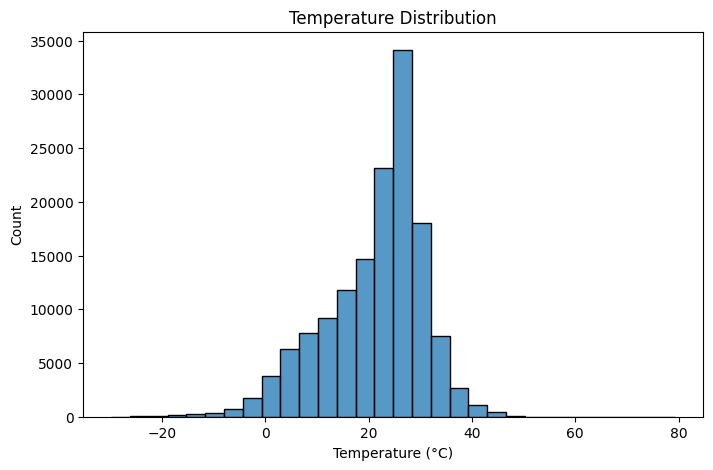

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(data['temperature_celsius'], bins=30)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Count")

plt.show()

Humidity Distribution

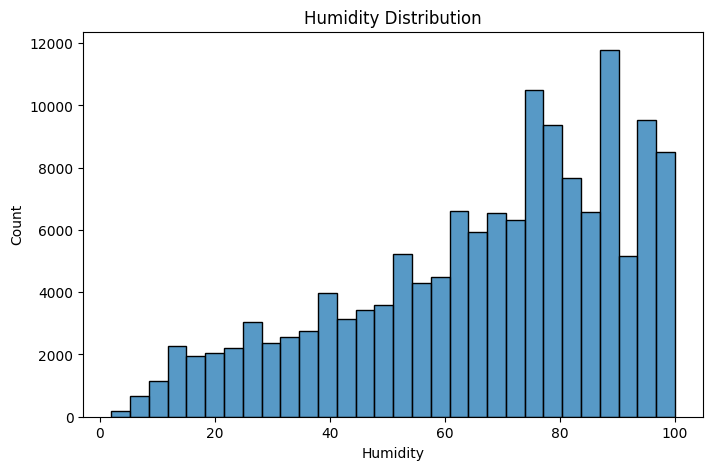

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(data['humidity'], bins=30)

plt.title("Humidity Distribution")
plt.xlabel("Humidity")
plt.ylabel("Count")

plt.show()

Correlation Heatmap

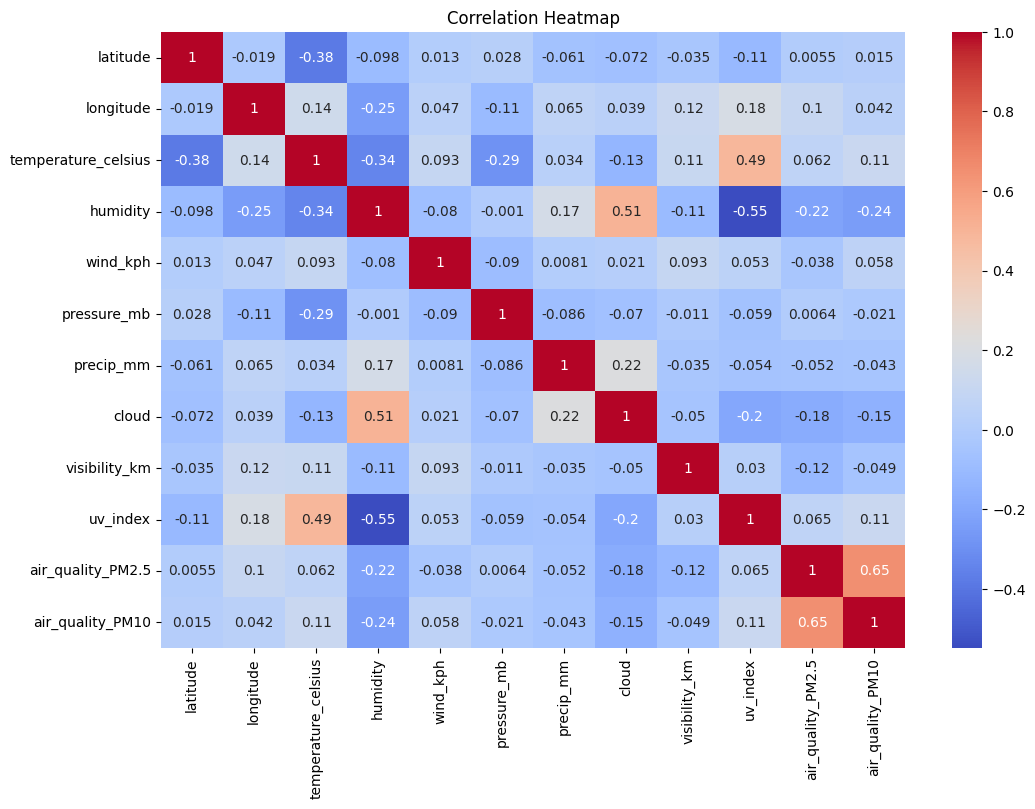

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Separate Numerical Features

In [12]:
features = [
    'latitude',
    'longitude',
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'pressure_mb',
    'precip_mm',
    'cloud',
    'visibility_km',
    'uv_index',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

# Numerical data for clustering
X = data[features]

# Display first 5 rows
print(X.head())

   latitude  longitude  temperature_celsius  humidity  wind_kph  pressure_mb  \
0     34.52      69.18                 26.6        24      13.3       1012.0   
1     41.33      19.82                 19.0        94      11.2       1012.0   
2     36.76       3.05                 23.0        29      15.1       1011.0   
3     42.50       1.52                  6.3        61      11.9       1007.0   
4     -8.84      13.23                 26.0        89      13.0       1011.0   

   precip_mm  cloud  visibility_km  uv_index  air_quality_PM2.5  \
0        0.0     30           10.0       7.0                8.4   
1        0.1     75           10.0       5.0                1.1   
2        0.0      0           10.0       5.0               10.4   
3        0.3    100            2.0       2.0                0.7   
4        0.0     50           10.0       8.0              183.4   

   air_quality_PM10  
0              26.6  
1               2.0  
2              18.4  
3               0.9  
4     

In [13]:
location_features = [
    'latitude',
    'longitude'
]

climate_features = [
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'pressure_mb',
    'precip_mm',
    'cloud',
    'visibility_km',
    'uv_index',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_climate = scaler.fit_transform(data[climate_features])

In [15]:
import numpy as np

scaled_data = np.concatenate(
    [data[location_features].values, scaled_climate],
    axis=1
)

print(scaled_data[:5])

[[ 3.45200000e+01  6.91800000e+01  5.56414415e-01 -1.80029853e+00
   3.98558239e-02 -2.01901204e-01 -2.37119335e-01 -2.86588897e-01
   1.80785894e-01  1.05961450e+00 -4.25737124e-01 -1.43387207e-01]
 [ 4.13300000e+01  1.98200000e+01 -2.34021623e-01  1.14516059e+00
  -1.43832522e-01 -2.01901204e-01 -5.85492453e-02  1.03423075e+00
   1.80785894e-01  4.93409570e-01 -6.27313111e-01 -3.10440238e-01]
 [ 3.67600000e+01  3.05000000e+00  1.81997344e-01 -1.58990860e+00
   1.97302978e-01 -3.00310955e-01 -2.37119335e-01 -1.16713533e+00
   1.80785894e-01  4.93409570e-01 -3.70510826e-01 -1.99071551e-01]
 [ 4.25000000e+01  1.52000000e+00 -1.55488184e+00 -2.43412998e-01
  -8.26030734e-02 -6.93949958e-01  2.98590934e-01  1.76801944e+00
  -2.79774840e+00 -3.55897823e-01 -6.38358370e-01 -3.17910089e-01]
 [-8.84000000e+00  1.32300000e+01  4.94011570e-01  9.34770651e-01
   1.36146316e-02 -3.00310955e-01 -2.37119335e-01  3.00442055e-01
   1.80785894e-01  1.34271696e+00  4.40656393e+00  1.45719814e+00]]


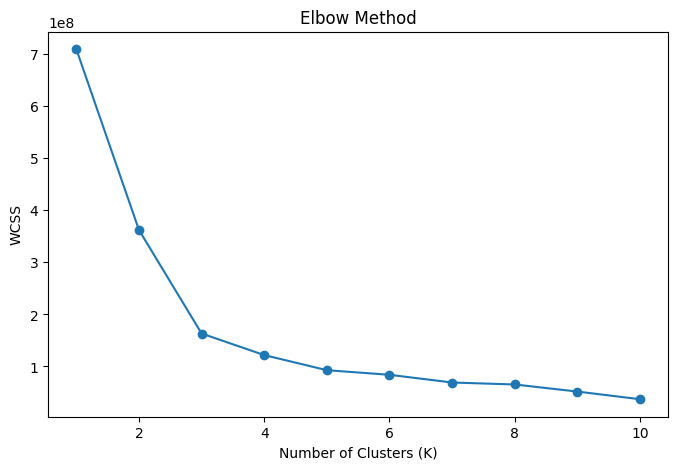

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Try different K values
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

In [17]:
# Create K-Means model
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

# Train model and predict clusters
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
data['Climate_Zone'] = clusters

# Display first 5 rows
print(data.head())

       country     location_name  latitude  longitude  temperature_celsius  \
0  Afghanistan             Kabul     34.52      69.18                 26.6   
1      Albania            Tirana     41.33      19.82                 19.0   
2      Algeria           Algiers     36.76       3.05                 23.0   
3      Andorra  Andorra La Vella     42.50       1.52                  6.3   
4       Angola            Luanda     -8.84      13.23                 26.0   

   humidity  wind_kph  pressure_mb  precip_mm  cloud  visibility_km  uv_index  \
0        24      13.3       1012.0        0.0     30           10.0       7.0   
1        94      11.2       1012.0        0.1     75           10.0       5.0   
2        29      15.1       1011.0        0.0      0           10.0       5.0   
3        61      11.9       1007.0        0.3    100            2.0       2.0   
4        89      13.0       1011.0        0.0     50           10.0       8.0   

   air_quality_PM2.5  air_quality_PM10  Clim

In [18]:
print(data['Climate_Zone'].value_counts())

Climate_Zone
0    91044
1    27204
2    25599
Name: count, dtype: int64


In [19]:
cluster_analysis = data.groupby('Climate_Zone').mean(numeric_only=True)

print(cluster_analysis)

               latitude   longitude  temperature_celsius   humidity  \
Climate_Zone                                                          
0             26.015371   23.379767            20.157414  61.142250   
1              6.424779  -78.146218            21.146026  83.674570   
2              8.648797  123.117699            25.246916  68.904098   

               wind_kph  pressure_mb  precip_mm      cloud  visibility_km  \
Climate_Zone                                                                
0             13.030567  1015.030337   0.089783  34.910428       9.267917   
1             11.888987  1014.380790   0.129528  44.579106       9.620383   
2             13.197336  1010.221063   0.289200  51.909020      10.278569   

              uv_index  air_quality_PM2.5  air_quality_PM10  
Climate_Zone                                                 
0             4.166376          23.515155         57.065858  
1             0.952198          16.591824         22.203202  
2         

In [20]:
climate_names = {
    0: 'Temperate',
    1: 'Humid',
    2: 'Tropical'
}

data['Climate_Name'] = data['Climate_Zone'].map(climate_names)

# Display first rows
print(data[['country', 'location_name', 'Climate_Zone', 'Climate_Name']].head())

       country     location_name  Climate_Zone Climate_Name
0  Afghanistan             Kabul             0    Temperate
1      Albania            Tirana             0    Temperate
2      Algeria           Algiers             0    Temperate
3      Andorra  Andorra La Vella             0    Temperate
4       Angola            Luanda             0    Temperate


In [21]:
print(
    data[
        ['country', 'location_name', 'temperature_celsius',
         'humidity', 'Climate_Name']
    ].sample(15)
)

                   country location_name  temperature_celsius  humidity  \
67483              Ecuador         Quito                  8.1        88   
15006              Myanmar        Yangon                 26.3        88   
22298              Albania        Tirana                 31.1        49   
80946                 Iraq       Baghdad                 39.4        20   
88648         Turkmenistan      Ashgabat                 33.0        20   
52769           San Marino    San Marino                 10.3        87   
62417              Eritrea        Asmara                 23.1        31   
86872      Solomon Islands       Honiara                 26.0        87   
19824                Gabon    Libreville                 30.4        66   
118841  Seychelles Islands      Victoria                 29.4        75   
51395             Portugal        Lisbon                 10.2        76   
115822             Finland      Helsinki                 -4.8        79   
133683               Syri

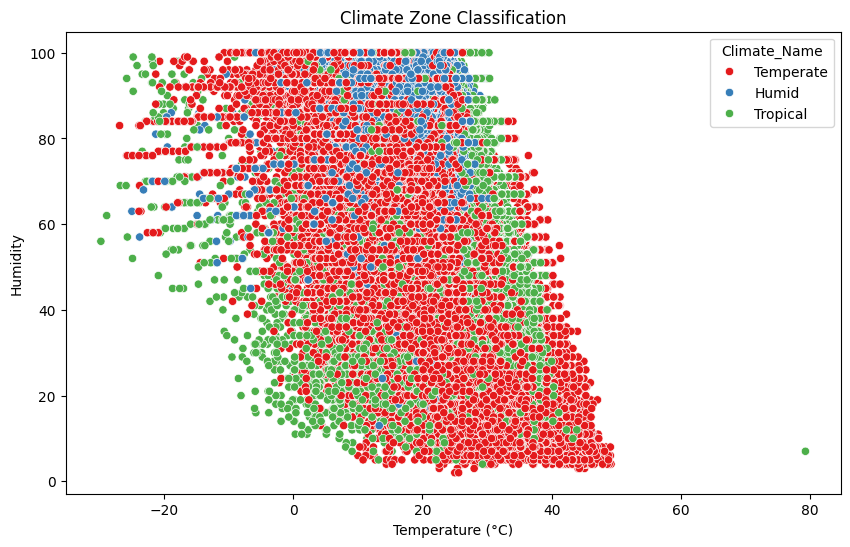

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=data['temperature_celsius'],
    y=data['humidity'],
    hue=data['Climate_Name'],
    palette='Set1'
)

plt.title("Climate Zone Classification")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity")

plt.show()

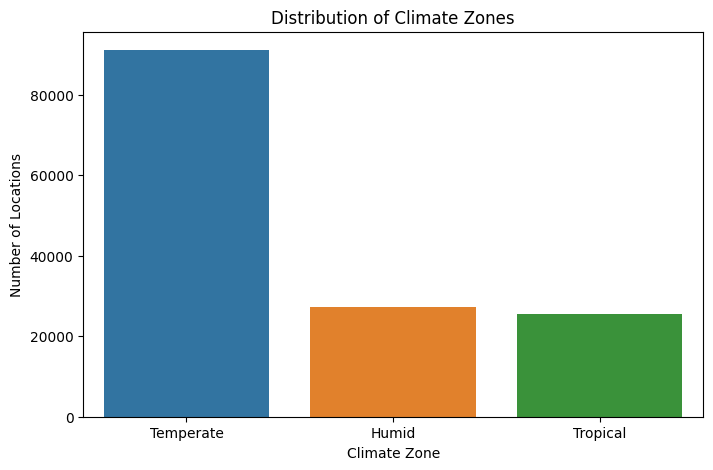

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Climate_Name',
    data=data,
    hue='Climate_Name'
)

plt.title("Distribution of Climate Zones")
plt.xlabel("Climate Zone")
plt.ylabel("Number of Locations")

plt.show()

In [26]:
# Save final dataset
data.to_csv(
    "classified_climate_data.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [27]:
import pickle

# Save trained K-Means model
with open("kmeans_climate_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

print("Model saved successfully!")

Model saved successfully!


In [28]:
# Save scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!


In [30]:
from sklearn.metrics import silhouette_score
import numpy as np

# Take random sample
sample_indices = np.random.choice(
    scaled_data.shape[0],
    10000,
    replace=False
)

sample_data = scaled_data[sample_indices]
sample_clusters = clusters[sample_indices]

# Calculate silhouette score
score = silhouette_score(sample_data, sample_clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.5601059595272525
